# ECMWF switch

Notebook to develop SEAS5 trigger to replaces IRI seasonal forecast.
SEAS5 trigger mechanism intended to match behaviour of IRI, keeping the same:

- issue months
- valid months
- geographic aggregation method (10% of area meets condition)

Note that return period cannot really be matched because return period of IRI
trigger was not estimated.

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [44]:
import calendar

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import statsmodels.api as sm

from src.datasources import seas5, iri, codab
from src.utils.raster import upsample_dataarray
from src.utils.rp_calc import calculate_groups_rp
from src.utils import blob_utils
from src.constants import *

## SEAS5

### Loading and processing

In [47]:
# if needed, process SEAS5 rasters (takes a few minutes)
# seas5.process_seas5_rasters()

In [5]:
df_seas5 = seas5.load_seas5_stats()

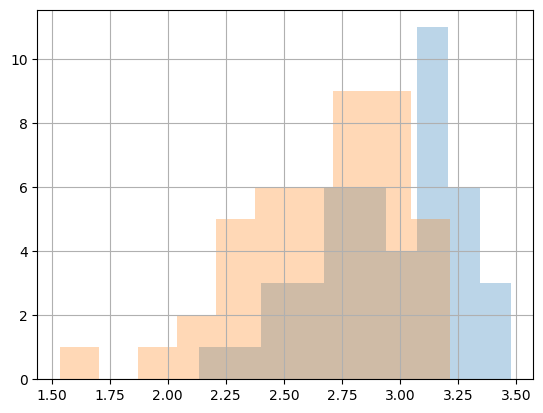

In [48]:
# just check the histogram to see that it's sensible
for issued_month, group in df_seas5.groupby("issued_month"):
    group["q"].hist(alpha=0.3)

In [7]:
df_seas5 = calculate_groups_rp(df_seas5, ["issued_month"])

In [8]:
df_seas5

,issued_month,year,q,q_rank,q_rp
0,3,1981,2.816667,16.0,2.812500
1,3,1982,3.105567,29.0,1.551724
2,3,1983,2.133250,1.0,45.000000
3,3,1984,2.438450,3.0,15.000000
4,3,1985,3.157980,34.0,1.323529
...,...,...,...,...,...
83,7,2020,2.422558,11.0,4.090909
84,7,2021,2.810514,26.0,1.730769
85,7,2022,3.009375,39.0,1.153846
86,7,2023,3.069366,40.0,1.125000


### Checking combined RP

In [9]:
df_pivot_rps = df_seas5.pivot(
    index="year", columns="issued_month", values="q_rp"
).reset_index()
df_pivot_rps = df_pivot_rps.rename(columns={x: f"issued_{x}" for x in [3, 7]})

In [12]:
dicts = []
min_individual_rp = 2

rp_list = df_seas5["q_rp"].unique()
rp_list = rp_list[rp_list >= min_individual_rp]
for rp_3 in rp_list:
    for rp_7 in rp_list:
        dff = df_pivot_rps[
            (df_pivot_rps["issued_3"] >= rp_3)
            | (df_pivot_rps["issued_7"] >= rp_7)
        ]
        dicts.append(
            {
                "rp_3": rp_3,
                "rp_7": rp_7,
                "rp_overall": (df_seas5["year"].nunique() + 1)
                / dff["year"].nunique(),
            }
        )
df_rps = pd.DataFrame(dicts)

In [13]:
heatmap_data = df_rps.pivot(index="rp_7", columns="rp_3", values="rp_overall")

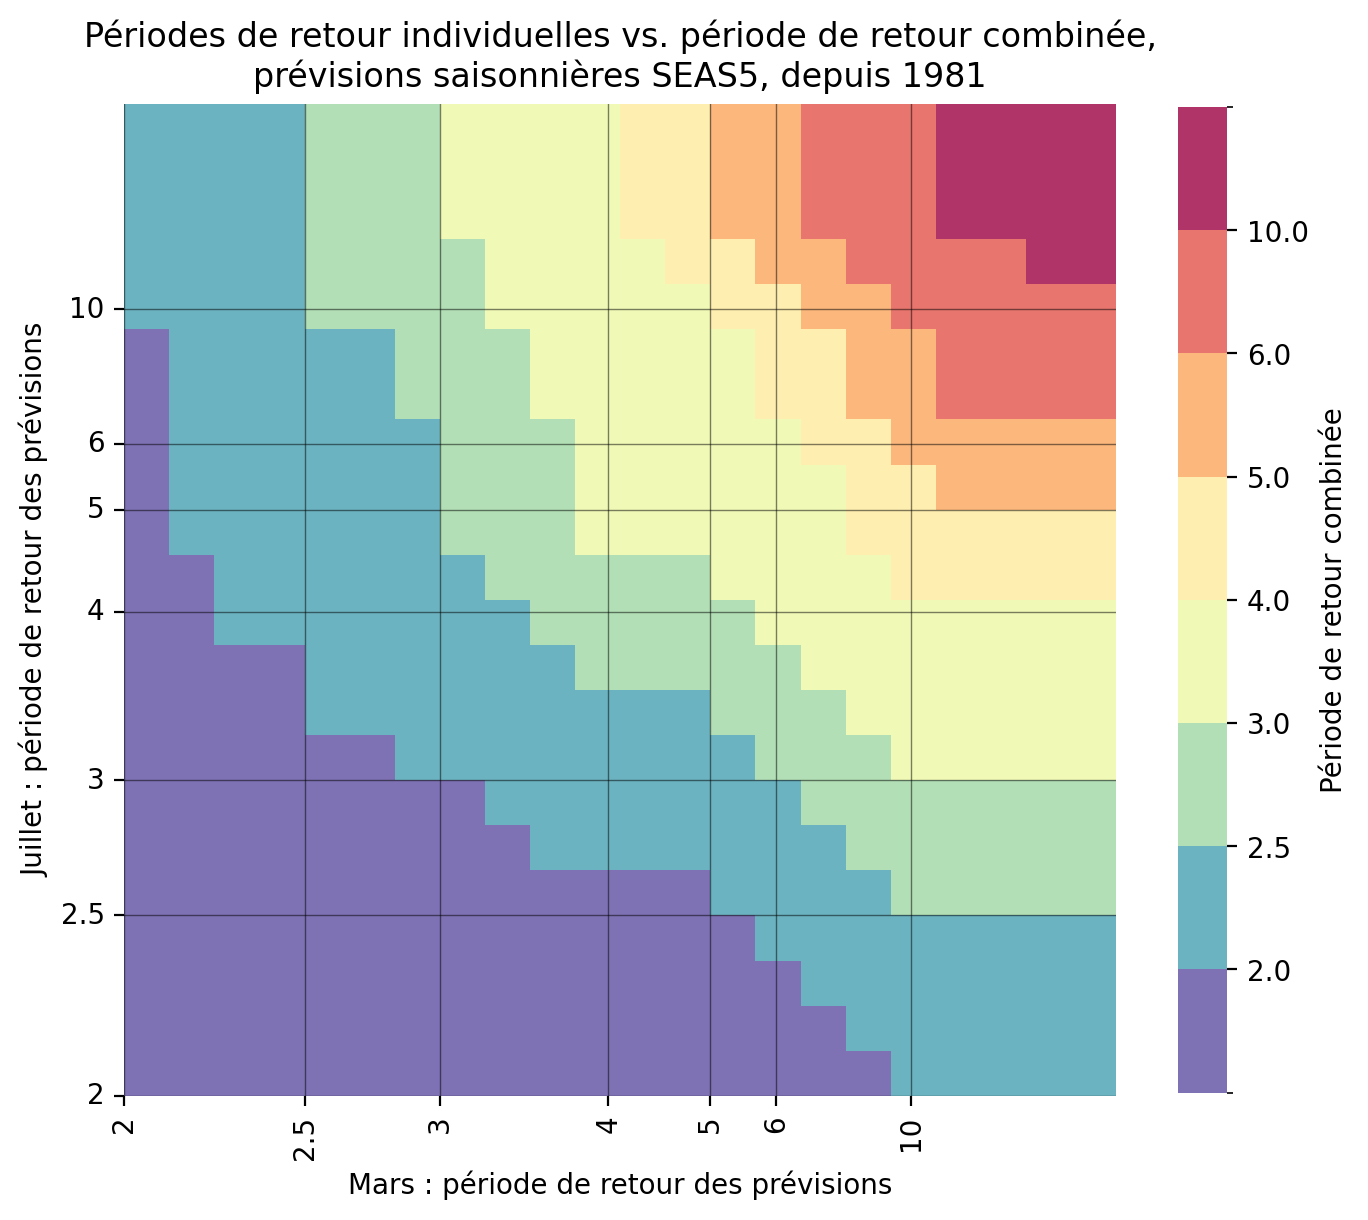

In [14]:
bounds = [1, 2, 2.5, 3, 4, 5, 6, 10, 1000]
tick_bounds = bounds[1:-1]
cmap = plt.cm.Spectral_r
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(dpi=200, figsize=(8, 8))

sns.heatmap(
    heatmap_data,
    annot=False,
    cmap=cmap,
    norm=norm,
    alpha=0.8,
    cbar_kws={
        "label": "Période de retour combinée",
        "ticks": tick_bounds,
        "shrink": 0.8,
    },
    ax=ax,
)
ax.invert_yaxis()
ax.set_aspect("equal", adjustable="box")
ax.set_title(
    "Périodes de retour individuelles vs. période de retour combinée,\n"
    f"prévisions saisonnières SEAS5, depuis {df_seas5['year'].min()}"
)
ax.set_xlabel("Mars : période de retour des prévisions")
ax.set_ylabel("Juillet : période de retour des prévisions")

tick_positions = np.interp(
    tick_bounds, heatmap_data.columns, range(len(heatmap_data.columns))
)
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_bounds, rotation=90)
ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_bounds)

for x in tick_positions:
    ax.axvline(x, color="k", alpha=0.5, linewidth=0.5)
    ax.axhline(x, color="k", alpha=0.5, linewidth=0.5)

plt.show()

Looks like taking 5 years for each month would yield a 
3-4 year combined RP.

### Check trend

In [15]:
df_pivot = df_seas5.pivot(
    index="year", columns="issued_month", values="q"
).reset_index()
df_pivot = df_pivot.rename(columns={x: f"issued_{x}" for x in [3, 7]})

<Axes: xlabel='year'>

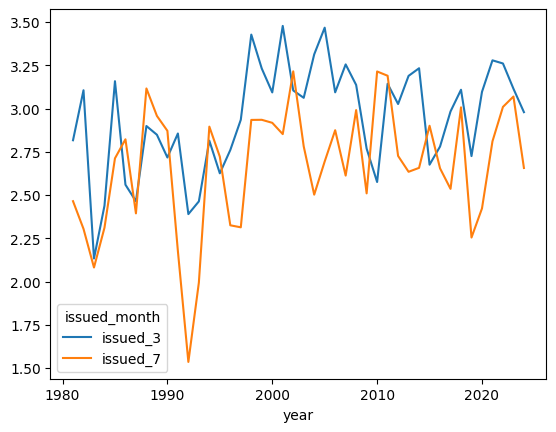

In [16]:
df_pivot.plot(x="year", y=["issued_3", "issued_7"])

In [17]:
for issued_month in [3, 7]:
    X = sm.add_constant(df_pivot.index)
    model = sm.OLS(df_pivot[f"issued_{issued_month}"], X).fit()
    print(f"issued month {issued_month}")
    print(model.summary())

issued month 3
                            OLS Regression Results                            
Dep. Variable:               issued_3   R-squared:                       0.184
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     9.450
Date:                Thu, 06 Feb 2025   Prob (F-statistic):            0.00370
Time:                        13:46:01   Log-Likelihood:                -6.1071
No. Observations:                  44   AIC:                             16.21
Df Residuals:                      42   BIC:                             19.78
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7217      0.084     

As a crude check, we see that the confidence intervals for the slope are 
positive. So we can try to filter to more recent years to hopefully 
make it trendless.

In [18]:
min_year = 2000
df_pivot_recent = df_pivot[df_pivot["year"] >= min_year]

<Axes: xlabel='year'>

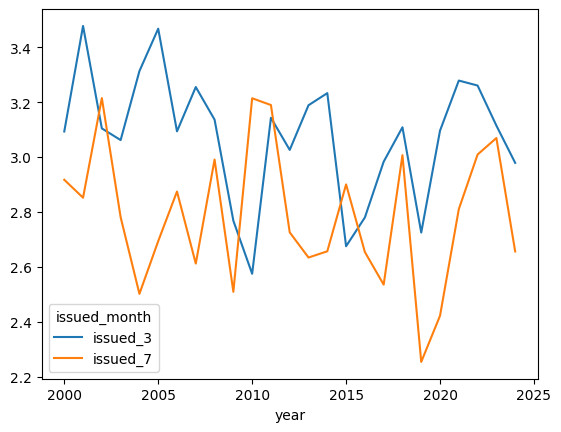

In [19]:
df_pivot_recent.plot(x="year", y=["issued_3", "issued_7"])

In [20]:
for issued_month in [3, 7]:
    X = sm.add_constant(df_pivot_recent.index)
    model = sm.OLS(df_pivot_recent[f"issued_{issued_month}"], X).fit()
    print(f"issued month {issued_month}")
    print(model.summary())

issued month 3
                            OLS Regression Results                            
Dep. Variable:               issued_3   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     1.617
Date:                Thu, 06 Feb 2025   Prob (F-statistic):              0.216
Time:                        13:46:03   Log-Likelihood:                 2.6812
No. Observations:                  25   AIC:                            -1.362
Df Residuals:                      23   BIC:                             1.075
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.3253      0.200     

Confidence intervals of slope span 0 now, so we're good.

In [21]:
df_pivot_recent

issued_month,year,issued_3,issued_7
19,2000,3.093123,2.917424
20,2001,3.477404,2.852145
21,2002,3.104388,3.214831
22,2003,3.061889,2.781333
23,2004,3.312969,2.502254
24,2005,3.467291,2.693998
25,2006,3.093643,2.874649
26,2007,3.254975,2.612396
27,2008,3.136335,2.990929
28,2009,2.768358,2.509659


### Plot historical activations

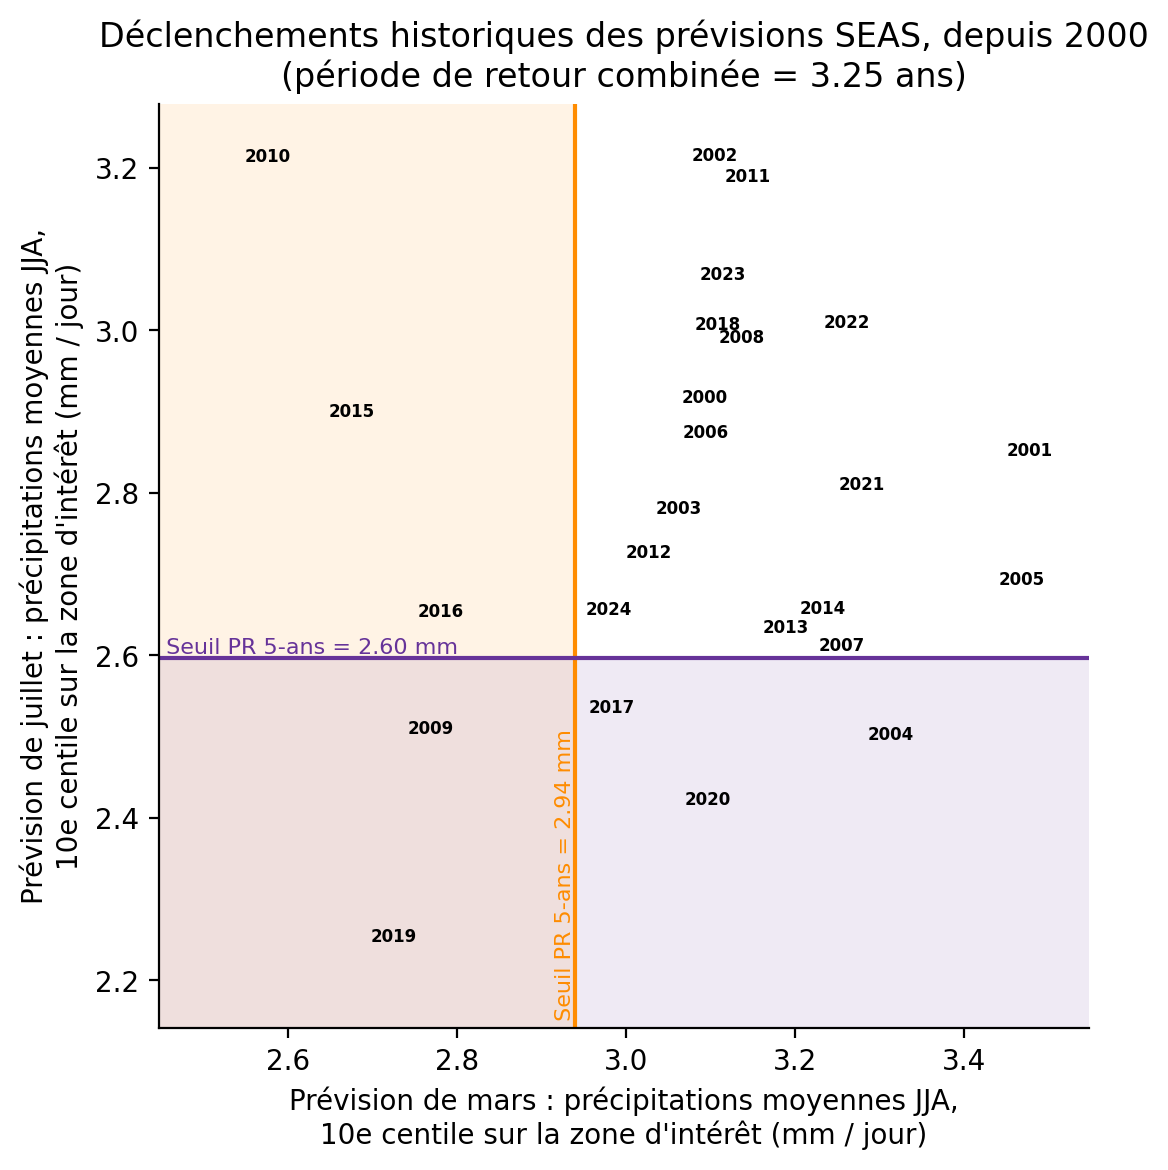

In [22]:
rp_individual_seas5 = 5

thresh_3 = df_pivot_recent["issued_3"].quantile(1 / rp_individual_seas5)
thresh_7 = df_pivot_recent["issued_7"].quantile(1 / rp_individual_seas5)

rp_overall = (len(df_pivot_recent) + 1) / df_pivot_recent[
    (df_pivot_recent["issued_3"] <= thresh_3)
    | (df_pivot_recent["issued_7"] <= thresh_7)
]["year"].nunique()

fig, ax = plt.subplots(dpi=200, figsize=(6, 6))

# uncomment to plot actual points
# df_pivot.plot(
#     x="issued_3",
#     y="issued_7",
#     ax=ax,
#     marker=".",
#     linewidth=0,
#     legend=False,
#     color="k",
# )

xmin = df_pivot_recent["issued_3"].min() * 0.95
xmax = df_pivot_recent["issued_3"].max() * 1.02
ymin = df_pivot_recent["issued_7"].min() * 0.95
ymax = df_pivot_recent["issued_7"].max() * 1.02

alpha = 0.1

color_3 = "darkorange"
ax.axvline(thresh_3, color=color_3)
ax.axvspan(xmin=xmin, xmax=thresh_3, facecolor=color_3, alpha=alpha)
ax.annotate(
    f" Seuil PR {rp_individual_seas5}-ans = {thresh_3:.2f} mm",
    (thresh_3, ymin),
    rotation=90,
    ha="right",
    va="bottom",
    fontsize=8,
    color=color_3,
)

color_7 = "rebeccapurple"
ax.axhline(thresh_7, color=color_7)
ax.axhspan(ymin=ymin, ymax=thresh_7, facecolor=color_7, alpha=alpha)
ax.annotate(
    f" Seuil PR {rp_individual_seas5}-ans = {thresh_7:.2f} mm",
    (xmin, thresh_7),
    ha="left",
    va="bottom",
    fontsize=8,
    color=color_7,
)

for year, row in df_pivot_recent.set_index("year").iterrows():
    ax.annotate(
        year,
        (row["issued_3"], row["issued_7"]),
        va="center",
        ha="center",
        fontsize=6,
        fontweight="bold",
    )

ax.set_xlim((xmin, xmax))
ax.set_ylim((ymin, ymax))

ax.set_xlabel(
    "Prévision de mars : précipitations moyennes JJA,\n"
    "10e centile sur la zone d'intérêt (mm / jour)"
)
ax.set_ylabel(
    "Prévision de juillet : précipitations moyennes JJA,\n"
    "10e centile sur la zone d'intérêt (mm / jour)"
)
ax.set_title(
    f"Déclenchements historiques des prévisions SEAS, depuis {min_year}\n"
    f"(période de retour combinée = {rp_overall:.2f} ans)"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

## IRI

### Load and process

In [27]:
adm1 = codab.load_codab_from_blob(admin_level=1, aoi_only=True)

Do same processing with IRI, although this is faster since it's reading a 
local file

In [28]:
ds_iri = iri.load_raw_iri()

In [29]:
da_iri = ds_iri.isel(C=0)["prob"]
da_iri = da_iri.rio.write_crs(4326)

In [30]:
da_iri_clip_low = da_iri.rio.clip(adm1.geometry, all_touched=True)

In [31]:
da_iri_up = upsample_dataarray(da_iri_clip_low, x_var="X", y_var="Y")

In [32]:
da_iri_clip = da_iri_up.rio.clip(adm1.geometry)

In [33]:
da_iri_q = da_iri_clip.quantile(1 - ORIGINAL_Q, dim=["X", "Y"])

/Users/tdowning/.pyenv/versions/pa-aa-bfa-drought/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


In [34]:
da_iri_q

<xarray.DataArray 'prob' (F: 90, L: 4)> Size: 3kB
array([[36.87176605, 41.49570896, 36.34841558, 43.81371869],
       [35.56794458, 39.74448608, 40.1201278 , 40.74299004],
       [37.65226503, 38.75978986, 36.040263  , 35.66628802],
       [36.29535791, 39.14386816, 37.51286156, 35.94592717],
       [27.68329477, 30.90674586, 33.35467664, 34.91578447],
       [33.87334627, 32.53759053, 34.67930315, 35.84345148],
       [34.43952021, 34.64073862, 35.28191074,         nan],
       [38.22765802, 34.9586569 ,         nan, 36.79762775],
       [36.90270733,         nan, 34.30044171, 40.00095152],
       [        nan, 36.26324382, 36.22015245, 37.9429175 ],
       [35.11357532, 37.32438088, 38.42268096, 37.89997006],
       [39.36392675, 36.61790271, 36.59295803, 34.81878087],
       [35.41390917, 36.90643982, 35.58538874, 37.31047238],
       [40.36375817, 35.10200021, 34.03972961, 31.14071715],
       [34.64013108, 34.34609797, 34.55175967, 37.79666497],
       [34.46922206, 30.25653927, 31.19261781, 35.64349359],
       [28.30688266, 28.93303925, 30.57008457, 28.33439227],
       [30.52200106, 30.43248605, 30.12664754, 38.38567027],
       [31.22169267, 32.25366147, 37.40074005,         nan],
       [27.86347162, 34.29291272,         nan, 37.33964037],
...
       [34.77320384, 35.08458214, 33.28991759, 32.79564343],
       [38.65630368, 28.42527292, 31.58363326, 32.95479825],
       [31.89833469, 30.22060076, 27.73415703, 30.6745168 ],
       [33.39944932, 29.63965301, 30.65164445, 25.8288393 ],
       [26.3835744 , 29.87296539, 30.52550524, 34.65220436],
       [34.06588183, 25.45567482, 27.13274434, 28.5034481 ],
       [32.77201172, 32.51489452, 27.41857094, 26.67873996],
       [30.44440043, 31.45604877, 23.75862177, 38.78594888],
       [29.56300771, 26.3208839 , 42.7060067 , 40.09200553],
       [20.4198695 , 30.23463741, 38.68907181, 37.82951402],
       [40.76729018, 32.95935233, 34.62554833, 34.45302132],
       [36.6841411 , 35.36589089, 33.98968533, 29.81360542],
       [34.97605244, 35.36100072, 32.43768558, 30.68812744],
       [32.98454958, 34.6531718 , 34.14027837, 31.39962694],
       [33.60580179, 35.25203835, 29.90044376, 23.83309154],
       [33.45279003, 30.68671804, 24.58739755, 20.45256604],
       [30.98680614, 25.42348453, 22.47432533, 28.44124945],
       [31.35446376, 23.66551432, 27.34194691, 33.15019869],
       [21.40306132, 24.01255086, 30.62684681, 31.91319897],
       [26.21163739, 29.5580317 , 39.59281195, 38.38478467]])
Coordinates:
  * L         (L) float32 16B 1.0 2.0 3.0 4.0
  * F         (F) object 720B 2017-02-16 00:00:00 ... 2024-07-16 00:00:00
    quantile  float64 8B 0.9

In [35]:
df_iri = da_iri_q.to_dataframe("q")["q"].reset_index()

In [36]:
df_iri["issued_date"] = pd.to_datetime(df_iri["F"].astype(str))
df_iri["issued_year"] = df_iri["issued_date"].dt.year
df_iri["issued_month"] = df_iri["issued_date"].dt.month

In [37]:
df_iri_triggers = df_iri[
    ((df_iri["issued_month"] == 3) & (df_iri["L"] == 3))
    | ((df_iri["issued_month"] == 7) & (df_iri["L"] == 1))
][["issued_year", "issued_month", "q"]].rename(columns={"issued_year": "year"})
df_iri_triggers

,year,issued_month,q
6,2017,3,40.120128
20,2017,7,33.873346
54,2018,3,34.039730
68,2018,7,30.522001
102,2019,3,38.090315
116,2019,7,30.107998
150,2020,3,31.348212
164,2020,7,33.793505
198,2021,3,30.255154
212,2021,7,38.541991


### Plot trend

<Axes: xlabel='year'>

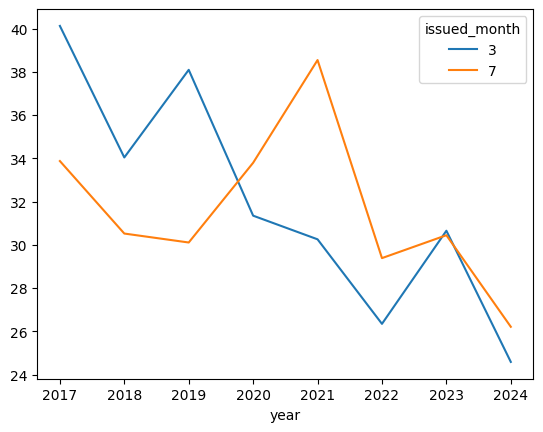

In [38]:
df_iri_triggers.pivot(index="year", columns="issued_month", values="q").plot()

In [39]:
df_iri_triggers

,year,issued_month,q
6,2017,3,40.120128
20,2017,7,33.873346
54,2018,3,34.039730
68,2018,7,30.522001
102,2019,3,38.090315
116,2019,7,30.107998
150,2020,3,31.348212
164,2020,7,33.793505
198,2021,3,30.255154
212,2021,7,38.541991


In [40]:
for issued_month in [3, 7]:
    dff = df_iri_triggers[df_iri_triggers["issued_month"] == issued_month]
    X = sm.add_constant(dff.index)
    model = sm.OLS(dff["q"], X).fit()
    print(f"issued month {issued_month}")
    print(model.summary())

issued month 3
                            OLS Regression Results                            
Dep. Variable:                      q   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     21.73
Date:                Thu, 06 Feb 2025   Prob (F-statistic):            0.00346
Time:                        13:47:03   Log-Likelihood:                -18.091
No. Observations:                   8   AIC:                             40.18
Df Residuals:                       6   BIC:                             40.34
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.9207      1.774     

/Users/tdowning/.pyenv/versions/pa-aa-bfa-drought/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "
/Users/tdowning/.pyenv/versions/pa-aa-bfa-drought/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [41]:
blob_name = f"{blob_utils.PROJECT_PREFIX}/processed/iri/iri_original_trigger_raster_stats.parquet"
blob_utils.upload_parquet_to_blob(df_iri_triggers, blob_name)

## Comparison

### Plot comparison plots

In [42]:
df_compare = df_seas5.merge(
    df_iri_triggers, on=["year", "issued_month"], suffixes=["_seas5", "_iri"]
)

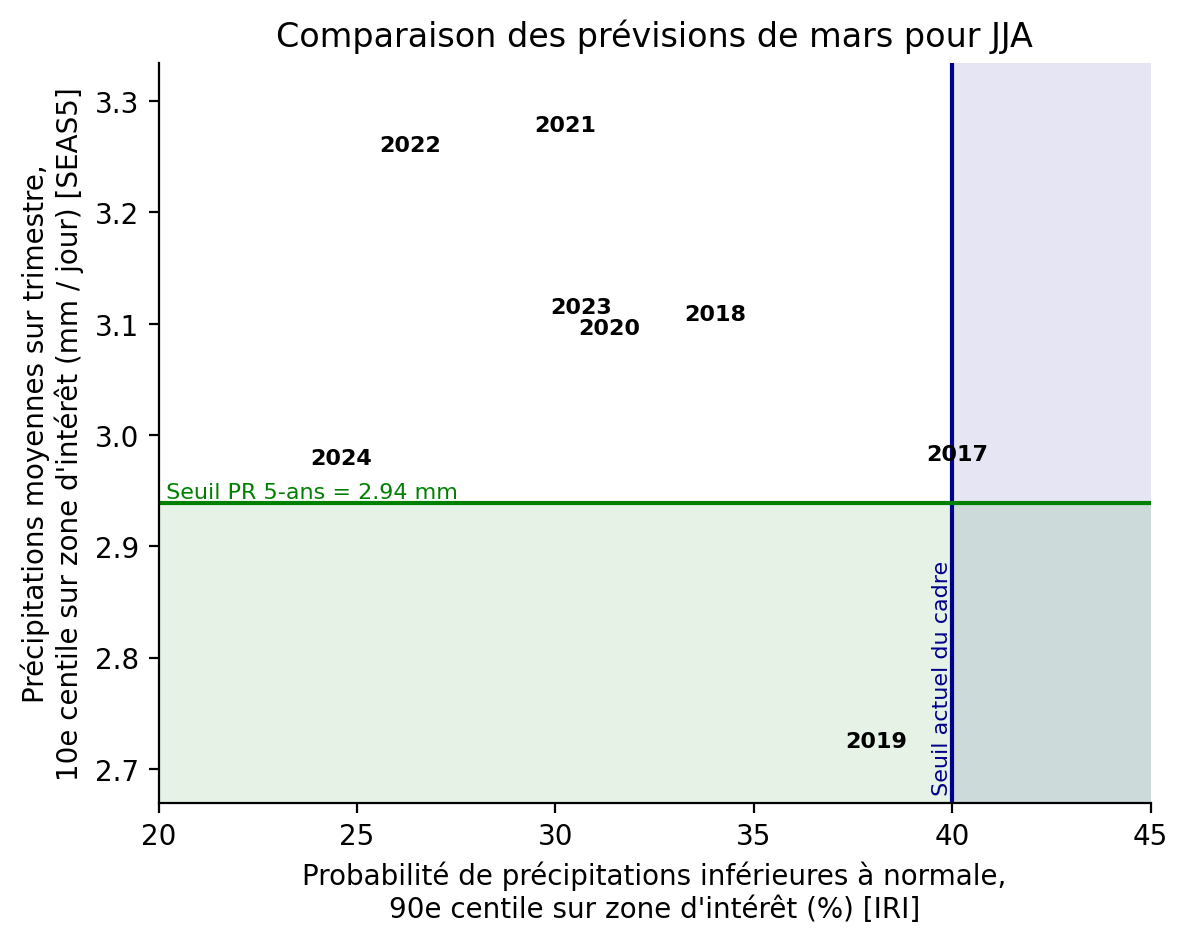

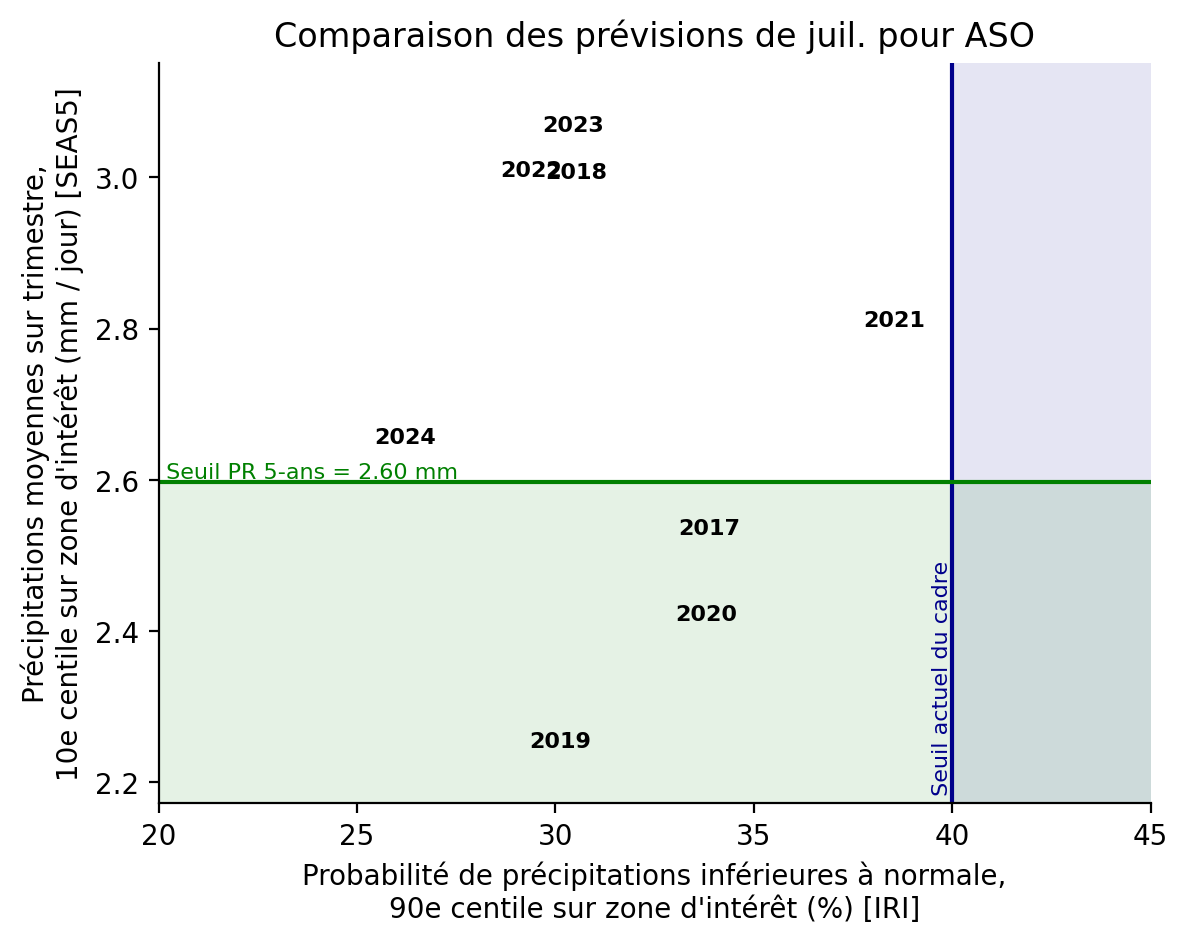

In [45]:
x_var = "q_iri"
y_var = "q_seas5"
x_color = "darkblue"
y_color = "green"
xmin, xmax = 20, 45
alpha = 0.1

for issued_month, seas5_thresh, trimester in zip(
    [3, 7], [thresh_3, thresh_7], ["JJA", "ASO"]
):
    fig, ax = plt.subplots(dpi=200)
    dff = df_compare[df_compare["issued_month"] == issued_month]

    for year, row in dff.set_index("year").iterrows():
        ax.annotate(
            year,
            (row[x_var], row[y_var]),
            va="center",
            ha="center",
            fontsize=8,
            fontweight="bold",
        )

    y_buffer = (dff[y_var].max() - dff[y_var].min()) * 0.1
    ymin, ymax = (
        dff[y_var].min() - y_buffer,
        dff[y_var].max() + y_buffer,
    )

    ax.axvline(ORIGINAL_IRI_THRESH, color=x_color)
    ax.axvspan(ORIGINAL_IRI_THRESH, xmax, facecolor=x_color, alpha=alpha)
    ax.annotate(
        " Seuil actuel du cadre",
        (ORIGINAL_IRI_THRESH, ymin),
        rotation=90,
        va="bottom",
        ha="right",
        fontsize=8,
        color=x_color,
    )

    ax.axhline(seas5_thresh, color=y_color)
    ax.axhspan(ymin, seas5_thresh, facecolor=y_color, alpha=alpha)
    ax.annotate(
        f" Seuil PR {rp_individual_seas5}-ans = {seas5_thresh:.2f} mm",
        (xmin, seas5_thresh),
        va="bottom",
        ha="left",
        fontsize=8,
        color=y_color,
    )

    ax.set_title(
        "Comparaison des prévisions de "
        f"{FRENCH_MONTHS.get(calendar.month_abbr[issued_month])} "
        f"pour {trimester}"
    )
    ax.set_ylabel(
        "Précipitations moyennes sur trimestre,\n"
        "10e centile sur zone d'intérêt (mm / jour) [SEAS5]"
    )
    ax.set_xlabel(
        f"Probabilité de précipitations inférieures à normale,\n"
        "90e centile sur zone d'intérêt (%) [IRI]"
    )

    ax.set_xlim((20, xmax))
    ax.set_ylim((ymin, ymax))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)